In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/basilatawneh/Students-Academic-Performance-Dataset-xAPI-Edu-Data-/master/xAPI-Edu-Data.csv')

# Display dataset info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (480, 17)


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [3]:
df.describe(include='all')

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
count,480,480,480,480,480,480,480,480,480,480.000000,480.000000,480.000000,480.000000,480,480,480,480
unique,2,14,14,3,10,3,12,2,2,NaN,NaN,NaN,NaN,2,2,2,3
top,M,KW,KuwaIT,MiddleSchool,G-02,A,IT,F,Father,NaN,NaN,NaN,NaN,Yes,Good,Under-7,M
freq,305,179,180,248,147,283,95,245,283,NaN,NaN,NaN,NaN,270,292,289,211
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.775000,54.797917,37.918750,43.283333,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.779223,33.080007,26.611244,27.637735,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.750000,20.000000,14.000000,20.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,65.000000,33.000000,39.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.000000,84.000000,58.000000,70.000000,NaN,NaN,NaN,NaN


In [4]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64


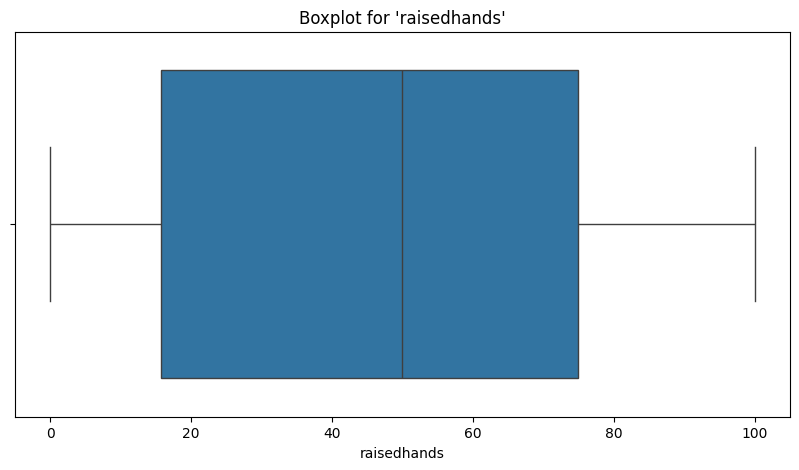

In [5]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['raisedhands'])
plt.title("Boxplot for 'raisedhands'")
plt.show()

In [6]:
z_scores = np.abs(stats.zscore(df.select_dtypes(include=np.number)))

threshold = 3
outliers = np.where(z_scores > threshold)

print("Outlier Indexes:\n", outliers)

Outlier Indexes:
 (array([], dtype=int64), array([], dtype=int64))


In [7]:
numeric_col = 'raisedhands'

Q1 = np.percentile(df[numeric_col], 25)
Q3 = np.percentile(df[numeric_col], 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers_iqr = df[(df[numeric_col] < lower_bound) | (df[numeric_col] > upper_bound)]
print("Outliers using IQR:\n", outliers_iqr)

Lower Bound: -73.125
Upper Bound: 163.875
Outliers using IQR:
 Empty DataFrame
Columns: [gender, NationalITy, PlaceofBirth, StageID, GradeID, SectionID, Topic, Semester, Relation, raisedhands, VisITedResources, AnnouncementsView, Discussion, ParentAnsweringSurvey, ParentschoolSatisfaction, StudentAbsenceDays, Class]
Index: []


In [8]:
df_clean = df[(df[numeric_col] >= lower_bound) & (df[numeric_col] <= upper_bound)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (480, 17)
After Removing Outliers: (480, 17)


In [9]:
scaler = MinMaxScaler()

num_cols = df_clean.select_dtypes(include=np.number).columns
df_scaled = df_clean.copy()

df_scaled[num_cols] = scaler.fit_transform(df_clean[num_cols])

df_scaled.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,0.15,0.161616,0.020408,0.193878,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,0.20,0.202020,0.030612,0.244898,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,0.10,0.070707,0.000000,0.295918,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,0.30,0.252525,0.051020,0.346939,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,0.40,0.505051,0.122449,0.500000,No,Bad,Above-7,M


In [10]:
scaler = StandardScaler()
df_standard = df_clean.copy()

df_standard[num_cols] = scaler.fit_transform(df_clean[num_cols])

df_standard.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-1.033429,-1.174075,-1.351167,-0.843326,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-0.870813,-1.053029,-1.313549,-0.662225,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-1.196046,-1.446426,-1.426401,-0.481125,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-0.545579,-0.901723,-1.238315,-0.300024,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-0.220346,-0.145191,-0.974994,0.243279,No,Bad,Above-7,M


In [11]:
scaler = RobustScaler()
df_robust = df_clean.copy()

df_robust[num_cols] = scaler.fit_transform(df_clean[num_cols])

df_robust.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-0.590717,-0.765625,-0.704545,-0.38,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-0.506329,-0.703125,-0.681818,-0.28,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-0.675105,-0.906250,-0.750000,-0.18,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-0.337553,-0.625000,-0.636364,-0.08,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,-0.168776,-0.234375,-0.477273,0.22,No,Bad,Above-7,M


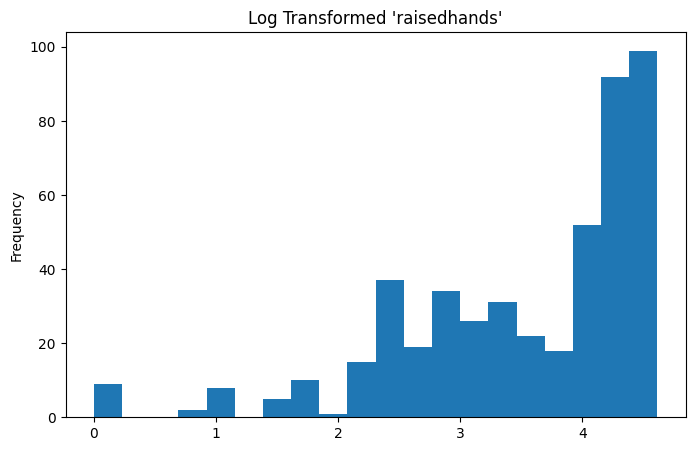

In [12]:
df_clean['log_raisedhands'] = np.log1p(df_clean['raisedhands'])

plt.figure(figsize=(8,5))
df_clean['log_raisedhands'].plot.hist(bins=20)
plt.title("Log Transformed 'raisedhands'")
plt.show()